# Inspect a SLAM session

Exploratory notebook (gitignored — promote reusable code to `polyumi_ingest` later).

**Goal:** dig into what ORB-SLAM3 actually did on *one* session, after `pingest pp 2` has run.

Point `SESSION` at a session directory. The notebook resolves it to the episode group inside
that scene's `scene.zarr` and plots the **forward** and **reverse** localization passes in the
raw SLAM frame.

Both passes come out of the localizer binary in one process, tracking against the *same* atlas,
so they are already in the same world frame — no alignment step is involved and any separation
you see between them is genuine disagreement about the same map. `slam_step._merge_forward_reverse`
gates the merge on their median position disagreement over the frames *both* tracked
(`reverse_merge_max_overlap_mm`, 50 mm). Under the gate, reverse fills forward's gaps; over it,
the reverse pass is discarded and `gopro/slam_poses` is forward-only.

| array | what it is |
|---|---|
| `gopro/slam_poses` | the merged result the rest of the pipeline consumes |
| `gopro/slam_poses_forward` | forward pass, un-merged |
| `gopro/slam_poses_reverse` | reverse pass, un-merged (absent if the reverse pass was off) |

All are `(N, 7) = [x, y, z, qx, qy, qz, qw]` on the GoPro frame grid, all-NaN in rows where that
pass had no pose.

In [71]:
# The 3D view is plotly (drag to orbit, scroll to zoom, hover a point for its frame index).
# matplotlib stays for the 2D timelines, where static output is fine and saves cleanly.
%matplotlib inline

import pathlib

import matplotlib.pyplot as plt
import numpy as np
import plotly.graph_objects as go
import zarr
from matplotlib.patches import Patch
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from scipy.spatial.transform import Rotation

from polyumi_ingest.episode_status import episode_keys
from polyumi_ingest.pzarr.scene_files import SceneFiles
from polyumi_ingest.timebase import nearest_idx

REPO = pathlib.Path.cwd()
if REPO.name == 'notebooks':
    REPO = REPO.parent  # allow running from notebooks/ or repo root
print('repo root:', REPO)

repo root: /home/user/Documents/W2026/winter_project/PolyUMI


## 1. Pick a session

In [72]:
# A session directory, repo-relative or absolute. Its scene.zarr must already have step 2 run.
# SESSION = 'recordings/scene_2026-07-29_16-01-53_2bd6/session_2026-07-29_16-05-53_226f'
# SESSION = 'recordings/scene_2026-07-29_16-01-53_2bd6/session_2026-07-29_16-06-29_53aa'
# SESSION = 'recordings/scene_2026-07-29_16-01-53_2bd6/session_2026-07-29_16-06-41_2fa0'
SESSION = 'recordings/scene_2026-07-29_13-26-45_f0b6/session_2026-07-29_13-41-42_0fd5'

# Also draw the merged gopro/slam_poses. Off by default: when the reverse pass was discarded
# the merged trajectory is forward exactly, so it just overdraws the forward line.
SHOW_MERGED = False

# Fit the 3D axes to one pass instead of to everything: 'forward', 'reverse', or None for both.
# A pass that has gone badly wrong covers metres while the good one covers centimetres, and on
# shared axes the good one collapses to a dot — set this to see it.
ZOOM_TO = None

# 'plotly'     — orbit/zoom/hover in the notebook output (VS Code renders this natively).
# 'matplotlib' — static image inline; set `%matplotlib tk` above and restart the kernel to get
#                the same figure in a separate OS window you can drag around.
BACKEND_3D = 'plotly'

# Superimpose this many pose triads (red=x, green=y, blue=z) on each trajectory, evenly spaced
# in *time* across its tracked span. 0 turns them off. plotly only.
N_POSE_AXES = 20
POSE_AXES_FOR = 'forward'  # 'forward' | 'reverse' | 'both' | None
POSE_AXIS_LEN = 0.05  # metres; None auto-sizes to ~7% of the plotted extent

## 2. Loaders

`session_dir` is written onto each episode group by `build_pzarr`, so it is the link from a
session directory back to its episode — the same lookup `resolve_gopro_mp4` uses to find an
episode's footage.

In [73]:
def resolve_session(session: str | pathlib.Path):
    """Return (root, ep_key, ep) for the episode built from this session directory."""
    session_path = pathlib.Path(session)
    if not session_path.is_absolute():
        session_path = REPO / session_path
    scene_zarr = SceneFiles.resolve_zarr_path(session_path.parent)
    if not scene_zarr.exists():
        raise FileNotFoundError(f'No scene.zarr beside {session_path} — run `pingest pp` on the scene first.')

    root = zarr.open_group(str(scene_zarr), mode='r')
    for key in episode_keys(root):
        if root[key].attrs.get('session_dir') == session_path.name:
            return root, key, root[key]
    known = [root[k].attrs.get('session_dir') for k in episode_keys(root)]
    raise KeyError(f'No episode in {scene_zarr} was built from {session_path.name}. Sessions present: {known}')


def load_pass(ep, name):
    """Return one pass as (N,7) float64 with NaN rows where it had no pose, or None if absent."""
    path = f'gopro/{name}'
    if path not in ep:
        return None
    return np.asarray(ep[path][:], dtype=np.float64)


def frame_times(ep):
    """GoPro frame timestamps in the finger clock (seconds since this episode's first frame)."""
    ts = np.asarray(ep['timestamps/gopro'][:], dtype=np.float64)
    if 'annotations/time_sync' in ep:
        ts = ts - float(ep['annotations/time_sync'].attrs.get('gopro_to_finger_offset_s', 0.0))
    return ts - ts[0]


def tracked_segments(poses, max_step):
    """
    Yield index arrays of consecutively-tracked rows, split at real tracking gaps.

    Do NOT just hand the raw (N,7) to plot() and rely on NaN to break the line. Under
    `frame_stride` > 1 the localizer is only fed every Nth frame, so every intermediate row is
    NaN *by construction* and every line segment would have a NaN endpoint — the plot comes out
    empty. A run continues while tracked rows stay `max_step` apart (= the stride); a larger
    jump is a genuine loss of tracking and starts a new segment.
    """
    valid = np.flatnonzero(~np.isnan(poses[:, 0]))
    if len(valid) == 0:
        return []
    breaks = np.flatnonzero(np.diff(valid) > max_step) + 1
    return [run for run in np.split(valid, breaks) if len(run)]

## 3. What step 2 recorded for this session

In [74]:
root, EP_KEY, ep = resolve_session(SESSION)
ann = dict(ep['annotations/slam'].attrs) if 'annotations/slam' in ep else {}

fwd = load_pass(ep, 'slam_poses_forward')
rev = load_pass(ep, 'slam_poses_reverse')
merged = load_pass(ep, 'slam_poses')
t_rel = frame_times(ep)


def _tracked(poses):
    return 0 if poses is None else int((~np.isnan(poses[:, 0])).sum())


print(f'{pathlib.Path(SESSION).name}  ->  {EP_KEY}  ({ep.attrs.get("session_type", "?")})')
print(f'  duration           {t_rel[-1]:.1f}s over {len(t_rel)} GoPro frames')
print(f'  frame_stride       {ann.get("frame_stride", 1)}  (every Nth frame is fed to the localizer)')
print(f'  frames fed         {ann.get("n_frames_fed", "?")}')
print(f'  tracking_ratio     {ann.get("tracking_ratio", float("nan")):.3f}  (of the frames fed, not of all frames)')
print(f'  relocalizations    {ann.get("n_relocalization_events", "?")}')
print()
print(f'  forward tracked    {_tracked(fwd)} / {len(t_rel)} frames')
print(f'  reverse tracked    {_tracked(rev)} / {len(t_rel)} frames')
print(f'  merged tracked     {_tracked(merged)} / {len(t_rel)} frames')

if ann.get('reverse_pass'):
    overlap_mm = ann.get('reverse_overlap_median_mm', float('nan'))
    verdict = 'MERGED' if ann.get('reverse_merged') else 'DISCARDED'
    print()
    print(f'  reverse pass       {verdict}')
    print(f'    shared frames    {ann.get("reverse_overlap_frames", "?")}')
    print(f'    median disagreement {overlap_mm:.1f} mm  (gate: 50 mm)')
    print(f'    frames it filled {ann.get("reverse_n_filled", 0)}')
else:
    print()
    print('  reverse pass       not run for this episode')

session_2026-07-29_13-41-42_0fd5  ->  episode_3  (EPISODE)
  duration           6.8s over 408 GoPro frames
  frame_stride       2  (every Nth frame is fed to the localizer)
  frames fed         204
  tracking_ratio     1.000  (of the frames fed, not of all frames)
  relocalizations    203

  forward tracked    204 / 408 frames
  reverse tracked    179 / 408 frames
  merged tracked     204 / 408 frames

  reverse pass       MERGED
    shared frames    179
    median disagreement 0.5 mm  (gate: 50 mm)
    frames it filled 0


## 4. Forward vs reverse in the SLAM frame

No transform is applied — these are the raw SLAM-frame positions, which is the frame the merge
gate judges them in. A break in a drawn line is a stretch where that pass genuinely lost
tracking; the regular `frame_stride` spacing is not treated as a gap (see `tracked_segments`).

Drag to orbit, scroll to zoom, and **hover any point to get its frame index and timestamp** —
that's the handle for tracing an excursion back to the video and the localizer log. Both
renderers are kept: `BACKEND_3D = 'matplotlib'` falls back to the static version, which becomes
a draggable OS window if you also switch the magic in the imports cell to `%matplotlib tk`.

`N_POSE_AXES` triads (red = camera x/right, green = y/down, blue = z/forward) ride on each trajectory, spaced evenly
in time rather than every k-th row, so a dropout doesn't bunch them. They show the rotation
*that pass* reported — the GoPro optical frame, not the hand frame step 5 retargets to —
which is what makes a position disagreement between the passes readable as either a shared path
walked differently or two genuinely different attitudes. Toggle them from the legend
independently of the trajectories.

In [75]:
def draw_axes(ax, origin, R, scale, label):
    """Draw RGB xyz axes at origin with orientation R (3x3, columns = x/y/z directions)."""
    for i, color in enumerate(('red', 'green', 'blue')):
        ax.quiver(
            *origin,
            R[0, i],
            R[1, i],
            R[2, i],
            length=scale,
            color=color,
            linewidth=1.5,
            arrow_length_ratio=0.2,
            label=f'{label} {"xyz"[i]}',
        )


def plot_passes_3d(ep, ep_key, fwd, rev, merged, ann, axis_scale=0.1, figsize=(12, 9)):
    """3D plot of the forward and reverse passes in the raw SLAM frame."""
    fig = plt.figure(figsize=figsize)
    ax = fig.add_subplot(111, projection='3d')
    stride = int(ann.get('frame_stride', 1) or 1)

    series = [
        (fwd, 'royalblue', 'forward pass', 1.4, 0.9),
        (rev, 'darkorange', 'reverse pass', 1.4, 0.9),
    ]
    if SHOW_MERGED:
        series.append((merged, 'black', 'merged (gopro/slam_poses)', 0.9, 0.5))

    for poses, color, label, lw, alpha in series:
        if poses is None:
            continue
        segments = tracked_segments(poses, stride)
        if not segments:
            print(f'{label}: no tracked poses, nothing to draw')
            continue
        for n, run in enumerate(segments):
            xyz = poses[run, :3]
            seg_label = label if n == 0 else None
            if len(run) == 1:
                ax.scatter(*xyz[0], color=color, marker='.', s=12, alpha=alpha, label=seg_label)
            else:
                ax.plot(xyz[:, 0], xyz[:, 1], xyz[:, 2], color=color, linewidth=lw, alpha=alpha, label=seg_label)
        first, last = segments[0][0], segments[-1][-1]
        ax.scatter(*poses[first, :3], color=color, marker='o', s=45, edgecolor='k', linewidth=0.5, zorder=5)
        ax.scatter(*poses[last, :3], color=color, marker='X', s=55, edgecolor='k', linewidth=0.5, zorder=5)
        if len(segments) > 1:
            print(f'{label}: {len(segments)} segments (tracking lost {len(segments) - 1}x)')

    # The SLAM frame origin: where the atlas puts (0,0,0), i.e. the map's own reference.
    draw_axes(ax, np.zeros(3), np.eye(3), axis_scale, 'SLAM')

    zoom = {'forward': fwd, 'reverse': rev}.get(ZOOM_TO)
    if zoom is not None:
        xyz = zoom[~np.isnan(zoom[:, 0]), :3]
        # A cube around this pass: equal aspect on a hand-set box only stays equal if the box
        # is already one, so build it that way rather than letting matplotlib reconcile it.
        centre = (xyz.max(axis=0) + xyz.min(axis=0)) / 2
        half = max((xyz.max(axis=0) - xyz.min(axis=0)).max() / 2, axis_scale) * 1.15
        ax.set_xlim(centre[0] - half, centre[0] + half)
        ax.set_ylim(centre[1] - half, centre[1] + half)
        ax.set_zlim(centre[2] - half, centre[2] + half)

    ax.set_xlabel('X (m)')
    ax.set_ylabel('Y (m)')
    ax.set_zlabel('Z (m)')

    overlap_mm = ann.get('reverse_overlap_median_mm', float('nan'))
    if ann.get('reverse_pass'):
        verdict = 'merged' if ann.get('reverse_merged') else 'reverse DISCARDED'
        subtitle = f'{verdict} — median forward/reverse disagreement {overlap_mm:.0f} mm (gate 50 mm)'
    else:
        subtitle = 'reverse pass not run'
    ax.set_title(
        f'{pathlib.Path(SESSION).name}  [{ep_key}]\n'
        f'{subtitle}\n'
        f'o = first tracked frame,  X = last',
        fontsize=9,
    )

    handles, labels = ax.get_legend_handles_labels()
    seen, dedup_h, dedup_l = set(), [], []
    for h, lbl in zip(handles, labels):
        if lbl not in seen:
            seen.add(lbl)
            dedup_h.append(h)
            dedup_l.append(lbl)
    ax.legend(dedup_h, dedup_l, fontsize=8, loc='upper left')

    ax.set_aspect('equal')
    fig.tight_layout()
    return fig, ax


def pose_axis_traces(poses, t_rel, name, n_axes, length):
    """
    Return three traces drawing ``n_axes`` pose triads, evenly spaced in time.

    Spacing is by *timestamp*, not by row: picking every len/N-th tracked row would bunch the
    triads wherever tracking was dense and skip whole seconds across a dropout. Targets are laid
    out uniformly between the first and last tracked time, then snapped to the nearest tracked
    frame (`timebase.nearest_idx`, the same helper the exporter resamples poses with).

    The triad is the rotation the pass reports for that frame: the columns of R are the camera
    optical axes expressed in the SLAM world frame, so red/green/blue are right/down/forward.
    """
    valid = np.flatnonzero(~np.isnan(poses[:, 0]))
    if n_axes < 1 or len(valid) < 2:
        return []
    t_valid = t_rel[valid]
    picks = np.unique(valid[nearest_idx(t_valid, np.linspace(t_valid[0], t_valid[-1], n_axes))])
    R = Rotation.from_quat(poses[picks, 3:]).as_matrix()  # (K,3,3), columns = body axes in world

    traces = []
    for i, (color, axis_label) in enumerate(zip(('red', 'green', 'blue'), 'xyz')):
        xs: list[float | None] = []
        ys: list[float | None] = []
        zs: list[float | None] = []
        hover: list[list[float]] = []
        for k, idx in enumerate(picks):
            p = poses[idx, :3]
            tip = p + length * R[k][:, i]
            # None breaks the line between triads, so all K segments ride in one trace.
            xs += [p[0], tip[0], None]
            ys += [p[1], tip[1], None]
            zs += [p[2], tip[2], None]
            hover += [[int(idx), float(t_rel[idx])]] * 3
        traces.append(
            go.Scatter3d(
                x=xs,
                y=ys,
                z=zs,
                mode='lines',
                line={'color': color, 'width': 5},
                name=f'{name} pose axes',
                legendgroup=f'{name} axes',
                showlegend=(i == 0),
                customdata=hover,
                hovertemplate=(
                    f'camera {axis_label}<br>frame %{{customdata[0]}}  t=%{{customdata[1]:.2f}}s'
                    f'<extra>{name}</extra>'
                ),
            )
        )
    return traces


def plotly_passes_3d(ep_key, fwd, rev, merged, ann, t_rel, axis_scale=0.1):
    """Same content as plot_passes_3d, as an orbitable plotly scene with per-point hover."""
    stride = int(ann.get('frame_stride', 1) or 1)
    fig = go.Figure()

    series = [(fwd, 'royalblue', 'forward pass'), (rev, 'darkorange', 'reverse pass')]
    if SHOW_MERGED:
        series.append((merged, 'black', 'merged (gopro/slam_poses)'))

    # Auto triad length: a fixed metre value is unusable across trajectories that range from
    # centimetres to metres. Scale to whatever the view is actually framing.
    zoom_pass = {'forward': fwd, 'reverse': rev}.get(ZOOM_TO)
    extent_from = [zoom_pass] if zoom_pass is not None else [p for p, _, _ in series if p is not None]
    tracked_xyz = np.concatenate([p[~np.isnan(p[:, 0]), :3] for p in extent_from])
    axis_len = POSE_AXIS_LEN or 0.07 * float((tracked_xyz.max(axis=0) - tracked_xyz.min(axis=0)).max())

    wanted = {'forward': {'forward pass'}, 'reverse': {'reverse pass'}, 'both': {'forward pass', 'reverse pass'}}.get(
        POSE_AXES_FOR, set()
    )

    for poses, color, name in series:
        if poses is None:
            continue
        for n, run in enumerate(tracked_segments(poses, stride)):
            fig.add_trace(
                go.Scatter3d(
                    x=poses[run, 0],
                    y=poses[run, 1],
                    z=poses[run, 2],
                    mode='lines' if len(run) > 1 else 'markers',
                    line={'color': color, 'width': 4},
                    marker={'color': color, 'size': 2},
                    name=name,
                    legendgroup=name,
                    showlegend=(n == 0),
                    # The point of the hover: read off *which frame* a bad excursion happened on,
                    # so it can be traced back to the video and the localizer log.
                    customdata=np.stack([run, t_rel[run]], axis=1),
                    hovertemplate=(
                        'frame %{customdata[0]}  t=%{customdata[1]:.2f}s<br>'
                        '(%{x:.3f}, %{y:.3f}, %{z:.3f}) m<extra>' + name + '</extra>'
                    ),
                )
            )
        if name in wanted:
            for trace in pose_axis_traces(poses, t_rel, name, N_POSE_AXES, axis_len):
                fig.add_trace(trace)

        runs = tracked_segments(poses, stride)
        if runs:
            for idx, symbol, tag in ((runs[0][0], 'circle', 'first'), (runs[-1][-1], 'x', 'last')):
                fig.add_trace(
                    go.Scatter3d(
                        x=[poses[idx, 0]],
                        y=[poses[idx, 1]],
                        z=[poses[idx, 2]],
                        mode='markers',
                        marker={'color': color, 'size': 6, 'symbol': symbol},
                        name=f'{name} ({tag} tracked)',
                        legendgroup=name,
                        showlegend=False,
                        hovertemplate=f'{tag} tracked frame {idx}<extra>{name}</extra>',
                    )
                )

    # SLAM frame axes at the atlas origin.
    for i, (color, label) in enumerate(zip(('red', 'green', 'blue'), 'xyz')):
        end = np.zeros(3)
        end[i] = axis_scale
        fig.add_trace(
            go.Scatter3d(
                x=[0, end[0]],
                y=[0, end[1]],
                z=[0, end[2]],
                mode='lines',
                line={'color': color, 'width': 6},
                name=f'SLAM {label}',
                showlegend=False,
                hoverinfo='skip',
            )
        )

    overlap_mm = ann.get('reverse_overlap_median_mm', float('nan'))
    if ann.get('reverse_pass'):
        verdict = 'merged' if ann.get('reverse_merged') else 'reverse DISCARDED'
        subtitle = f'{verdict} — median forward/reverse disagreement {overlap_mm:.0f} mm (gate 50 mm)'
    else:
        subtitle = 'reverse pass not run'

    scene = {
        'xaxis_title': 'X (m)',
        'yaxis_title': 'Y (m)',
        'zaxis_title': 'Z (m)',
        'aspectmode': 'data',  # equal aspect; 'cube' would distort the trajectory shape
    }
    zoom = {'forward': fwd, 'reverse': rev}.get(ZOOM_TO)
    if zoom is not None:
        xyz = zoom[~np.isnan(zoom[:, 0]), :3]
        centre = (xyz.max(axis=0) + xyz.min(axis=0)) / 2
        half = max((xyz.max(axis=0) - xyz.min(axis=0)).max() / 2, axis_scale) * 1.15
        for i, axis in enumerate(('xaxis', 'yaxis', 'zaxis')):
            scene[axis] = {'range': [centre[i] - half, centre[i] + half]}
        scene['aspectmode'] = 'cube'  # the ranges are already a cube, so this stays undistorted

    fig.update_layout(
        title={'text': f'{pathlib.Path(SESSION).name}  [{ep_key}]<br><sup>{subtitle}</sup>', 'font': {'size': 13}},
        scene=scene,
        height=720,
        margin={'l': 0, 'r': 0, 't': 60, 'b': 0},
        legend={'x': 0, 'y': 1},
    )
    return fig


if BACKEND_3D == 'plotly':
    fig3d = plotly_passes_3d(EP_KEY, fwd, rev, merged, ann, t_rel)
    fig3d.show()
else:
    fig, ax = plot_passes_3d(ep, EP_KEY, fwd, rev, merged, ann)
    plt.show()

## 5. Where the two passes disagree

The 3D view shows *that* they separate; this shows *where* along the episode. The merge gate is a
single median over the shared frames, so a trajectory that agrees early and diverges late looks
the same to it as one that is uniformly offset — but they mean very different things. A uniform
offset is a frame/scale disagreement; a growing one is drift in one of the passes.

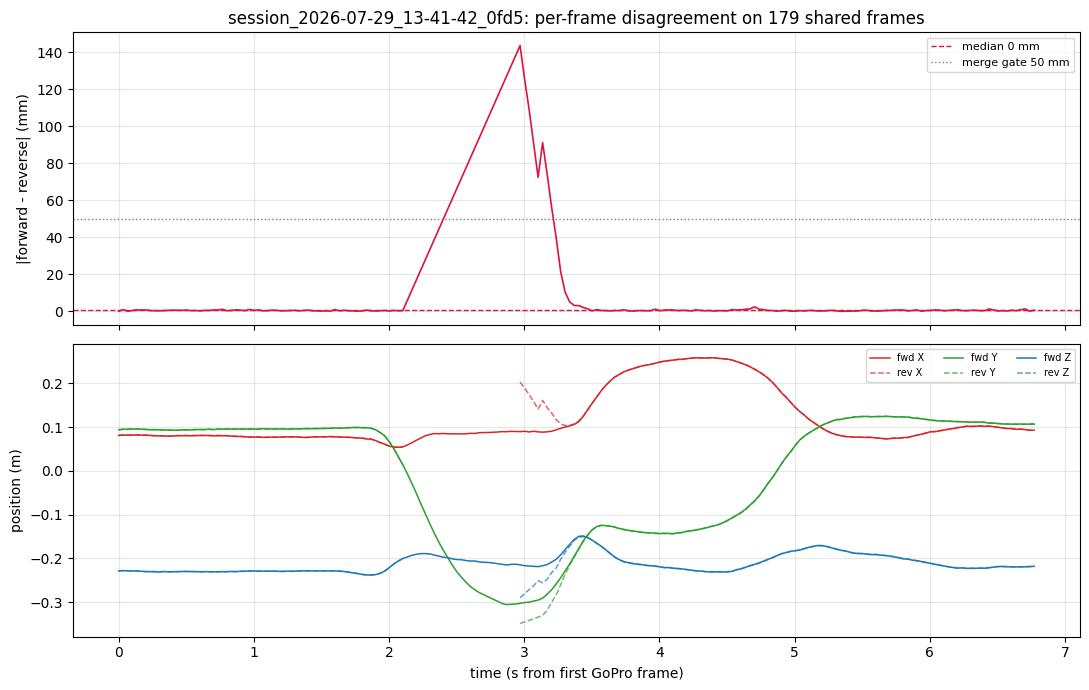

In [76]:
if fwd is None or rev is None:
    print('Need both passes for this comparison.')
else:
    both = ~np.isnan(fwd[:, 0]) & ~np.isnan(rev[:, 0])
    if both.sum() < 3:
        print(f'Only {both.sum()} frames tracked by both passes — too few to compare.')
    else:
        dist_mm = np.linalg.norm(fwd[both, :3] - rev[both, :3], axis=1) * 1000.0
        median_mm = float(np.median(dist_mm))

        fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

        axes[0].plot(t_rel[both], dist_mm, color='crimson', linewidth=1.2)
        axes[0].axhline(median_mm, color='crimson', linestyle='--', linewidth=1, label=f'median {median_mm:.0f} mm')
        axes[0].axhline(50.0, color='gray', linestyle=':', linewidth=1, label='merge gate 50 mm')
        axes[0].set_ylabel('|forward - reverse| (mm)')
        axes[0].set_title(f'{pathlib.Path(SESSION).name}: per-frame disagreement on {int(both.sum())} shared frames')
        axes[0].legend(fontsize=8)
        axes[0].grid(alpha=0.3)

        stride = int(ann.get('frame_stride', 1) or 1)
        for i, (name, color) in enumerate(zip('XYZ', ('tab:red', 'tab:green', 'tab:blue'))):
            for poses, style, alpha, tag in ((fwd, '-', 1.0, 'fwd'), (rev, '--', 0.7, 'rev')):
                for n, run in enumerate(tracked_segments(poses, stride)):
                    axes[1].plot(
                        t_rel[run],
                        poses[run, i],
                        color=color,
                        linestyle=style,
                        linewidth=1.1,
                        alpha=alpha,
                        label=f'{tag} {name}' if n == 0 else None,
                    )
        axes[1].set_xlabel('time (s from first GoPro frame)')
        axes[1].set_ylabel('position (m)')
        axes[1].legend(fontsize=7, ncol=3)
        axes[1].grid(alpha=0.3)

        fig.tight_layout()
        plt.show()

## 6. Tracked vs lost, per pass

The `slam_tuning_explore` per-frame timeline (its §4), for this one session: forward, reverse,
and merged stacked so the merge's effect is a visual diff of the bottom row against the top two.

**Drawn on the frames actually fed to the localizer, not the full GoPro grid.** Under
`frame_stride: 2` only every second frame is ever handed to ORB-SLAM3, so the rows in between
are NaN because nothing looked at them — plotting the raw grid would render half of a healthy
episode as "lost" in a 1-frame-wide red/blue barcode. Fed frames are uniformly spaced, so the
time axis stays exact; each bar cell covers `stride` frames.

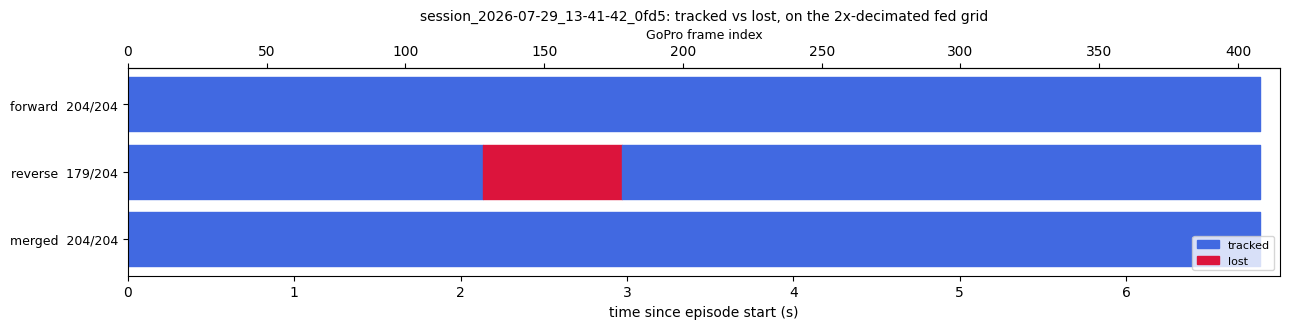

In [77]:
def gap_runs_mask(valid):
    """Contiguous (start, length, is_valid) runs over a boolean mask, in order."""
    runs, i, n = [], 0, len(valid)
    while i < n:
        j = i
        while j < n and valid[j] == valid[i]:
            j += 1
        runs.append((i, j - i, bool(valid[i])))
        i = j
    return runs


def fed_mask(poses, stride):
    """(fed_indices, tracked) over just the frames the localizer was given."""
    fed = np.arange(0, len(poses), stride)
    return fed, ~np.isnan(poses[fed, 0])


def plot_tracking_timeline(fwd, rev, merged, ann, t_rel, figsize=(13, 3.4)):
    """Stacked tracked/lost bars for the forward, reverse and merged passes."""
    stride = int(ann.get('frame_stride', 1) or 1)
    dt = float(t_rel[stride] - t_rel[0]) if len(t_rel) > stride else 1.0

    fig, ax = plt.subplots(figsize=figsize)
    labels = []
    for row, (name, poses) in enumerate((('forward', fwd), ('reverse', rev), ('merged', merged))):
        if poses is None:
            labels.append(f'{name} (absent)')
            continue
        fed, tracked = fed_mask(poses, stride)
        for start, length, is_tracked in gap_runs_mask(tracked):
            ax.broken_barh(
                [(t_rel[fed[start]], length * dt)],
                (row - 0.4, 0.8),
                color='royalblue' if is_tracked else 'crimson',
            )
        labels.append(f'{name}  {tracked.sum()}/{len(fed)}')

    ax.set_yticks(range(3))
    ax.set_yticklabels(labels, fontsize=9)
    ax.invert_yaxis()  # forward on top
    ax.set_xlim(0, t_rel[-1] * 1.02)
    ax.set_xlabel('time since episode start (s)')

    # Frame index is what you need to seek in the video or grep the localizer log for.
    frame_axis = ax.secondary_xaxis('top', functions=(lambda t: t / (t_rel[1] - t_rel[0]), lambda i: i * (t_rel[1] - t_rel[0])))
    frame_axis.set_xlabel('GoPro frame index', fontsize=9)

    ax.set_title(f'{pathlib.Path(SESSION).name}: tracked vs lost, on the {stride}x-decimated fed grid', fontsize=10)
    ax.legend(
        handles=[Patch(color='royalblue', label='tracked'), Patch(color='crimson', label='lost')],
        loc='lower right',
        fontsize=8,
    )
    fig.tight_layout()
    return fig, ax


fig, ax = plot_tracking_timeline(fwd, rev, merged, ann, t_rel)
plt.show()